# 02 · Carr-Madan FFT — Heston & Variance Gamma

Phase 2: one FFT call prices all $N$ strikes.  O(N·n) → O(n log n).

$$\psi_T(v) = \frac{e^{-rT}\varphi(v-(\alpha+1)i)}{\alpha^2+\alpha-v^2+i(2\alpha+1)v}\qquad C_T(k) = \frac{e^{-\alpha k}}{\pi}\operatorname{Re}\int_0^\inftye^{-ivk}\psi_T(v)\,dv$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.interpolate import CubicSpline
import time
def bs_call(S, K, T, r, sigma, q=0.0):
    S, K, sigma = map(np.asarray, [S, K, sigma])
    F = S * np.exp((r - q) * T); sqT = np.sqrt(T)
    d1 = (np.log(F / K) + 0.5*sigma**2*T) / (sigma*sqT)
    return np.exp(-r*T) * (F*norm.cdf(d1) - K*norm.cdf(d1 - sqT*sigma))


## Characteristic functions

In [2]:
def heston_cf(u, T, kappa, theta, nu, rho, v0):
    """CF of log(S_T/F_0) — Albrecher Formulation 2 (branch-cut safe)."""
    u = np.asarray(u, complex)
    b = kappa - 1j*rho*nu*u
    d = np.sqrt(b**2 + nu**2*(u**2 + 1j*u))
    g = (b-d)/(b+d); e = np.exp(-d*T)
    D = (b-d)*(1-e) / (nu**2*(1-g*e))
    C = kappa*theta/nu**2 * ((b-d)*T - 2*np.log((1-g*e)/(1-g)))
    return np.exp(C + D*v0)

def vg_cf(u, T, sigma, nu, theta_vg):
    """CF of log(S_T/F_0) — Variance Gamma (includes ω convexity correction)."""
    u = np.asarray(u, complex)
    omega = np.log(1 - theta_vg*nu - 0.5*sigma**2*nu) / nu
    return (np.exp(1j*u*omega*T)
            * (1 - 1j*u*theta_vg*nu + 0.5*sigma**2*nu*u**2)**(-T/nu))

# martingale check: φ(0)=1, φ(-i)=1 for both
for name, fn, kw in [
    ('Heston', heston_cf, dict(T=1.,kappa=4.,theta=.25,nu=1.,rho=-.5,v0=.04)),
    ('VG',     vg_cf,     dict(T=.25,sigma=.25,nu=2.,theta_vg=-.10)),
]:
    u_chk = np.array([0+0j, -1j])
    vals  = fn(u_chk, **kw)
    print(f"{name:<8} φ(0)={vals[0].real:.6f}  φ(-i)={vals[1].real:.6f}  (both must = 1.0)")


Heston   φ(0)=1.000000  φ(-i)=1.000000  (both must = 1.0)
VG       φ(0)=1.000000  φ(-i)=1.000000  (both must = 1.0)


## Carr-Madan FFT engine

In [3]:
def carr_madan_fft(phi_logS, r, T, alpha=1.5, N=4096, eta=0.25):
    """
    phi_logS(u) = E[exp(iu·log S_T)]  (includes S0 and forward drift).
    Returns (K_grid, C_grid) — call prices on a log-strike grid.
    Use fft_price() for arbitrary strikes.
    """
    lam = 2*np.pi/(N*eta); b = N*lam/2
    j = np.arange(N, dtype=float); v = j*eta
    psi = (np.exp(-r*T) * phi_logS(v - 1j*(alpha+1))
           / (alpha**2 + alpha - v**2 + 1j*(2*alpha+1)*v))
    w = np.ones(N); w[0]=w[-1]=1/3; w[1:-1:2]=4/3; w[2:-2:2]=2/3
    Z = np.fft.fft(np.exp(1j*v*b)*psi*eta*w)
    k = -b + lam*j
    return np.exp(k), np.real(np.exp(-alpha*k)/np.pi * Z)

def fft_price(phi_logS, K_targets, r, T, alpha=1.5, N=4096, eta=0.25):
    """FFT → cubic-spline → prices at arbitrary strikes."""
    Kg, Cg = carr_madan_fft(phi_logS, r, T, alpha, N, eta)
    mask = (Cg > 0) & (Kg > 0.5) & (Kg < 5000)
    return CubicSpline(np.log(Kg[mask]), Cg[mask])(np.log(np.asarray(K_targets, float)))

def make_phi(S0, T, r, q, cf_logX):
    """Shift CF of log(S_T/F_0) → CF of log(S_T)."""
    return lambda u: np.exp(1j*u*(np.log(S0)+(r-q)*T)) * cf_logX(u)


## Validation 1 — CM1999 Case 4 (VG, PUT prices)

CM1999 Table 1, Case 4: $\sigma=0.25,\nu=2,\theta=-0.10,T=0.25,S_0=100,r=0.05,q=0.03$.  Reference prices at $K=77$–$79$ are European **puts**.  We price calls via FFT then convert: $P = C - S_0 e^{-qT} + Ke^{-rT}$.

In [4]:
S0,T,r,q = 100.,0.25,0.05,0.03
phi_vg = make_phi(S0, T, r, q,
                  lambda u: vg_cf(u, T, 0.25, 2.0, -0.10))

K_vg  = np.array([77.,78.,79.])
C_vg  = fft_price(phi_vg, K_vg, r, T)
P_vg  = C_vg - S0*np.exp(-q*T) + K_vg*np.exp(-r*T)
REF_VG = np.array([0.6356, 0.6787, 0.7244])

print(f"{'K':>5}  {'FFT call':>10}  {'FFT put':>10}  {'CM1999':>8}  {'|err|':>10}  pass?")
for k,c,p,ref in zip(K_vg, C_vg, P_vg, REF_VG):
    ok = abs(p-ref) < 1e-4
    print(f"  {k:3.0f}  {c:10.4f}  {p:10.6f}  {ref:8.4f}  {abs(p-ref):10.2e}  {'✓' if ok else '✗'}")


    K    FFT call     FFT put    CM1999       |err|  pass?
   77     23.8450    0.635638    0.6356    3.80e-05  ✓
   78     22.9004    0.678708    0.6787    7.89e-06  ✓
   79     21.9586    0.724439    0.7244    3.88e-05  ✓


## Validation 2 — Lewis (2001) 15-digit Heston benchmark

$r=0.01,q=0.02,S_0=100,T=1,v_0=0.04,\kappa=4,\theta=0.25,\nu=1,\rho=-0.5$.  Target $|\text{err}|<10^{-4}$.

In [5]:
S0h,Th,rh,qh = 100.,1.,0.01,0.02
phi_h = make_phi(S0h, Th, rh, qh,
                 lambda u: heston_cf(u,Th,4.,0.25,1.,-0.5,0.04))

LEWIS = {80:26.774758743998854, 90:20.933349000596710,
         100:16.070154917028834,110:12.132211516709845,120:9.024913483457836}
K_l = np.array(list(LEWIS.keys()),float)
C_l = fft_price(phi_h, K_l, rh, Th)
REF = np.array(list(LEWIS.values()))

print(f"{'K':>6}  {'FFT':>16}  {'Lewis 15-dig':>18}  {'|err|':>12}  pass?")
for k,c,ref in zip(K_l,C_l,REF):
    ok = abs(c-ref)<1e-4
    print(f"  {k:5.0f}  {c:16.8f}  {ref:18.12f}  {abs(c-ref):12.2e}  {'✓' if ok else '✗'}")


     K               FFT        Lewis 15-dig         |err|  pass?
     80       26.77475853     26.774758743999      2.13e-07  ✓
     90       20.93334879     20.933349000597      2.13e-07  ✓
    100       16.07015471     16.070154917029      2.12e-07  ✓
    110       12.13221130     12.132211516710      2.13e-07  ✓
    120        9.02491327      9.024913483458      2.11e-07  ✓


## TODO A — Damping parameter α sensitivity

α must satisfy $0 < \alpha < $ upper bound of the regularity strip.  For Heston this is approximately $\alpha < \kappa/|\rho\nu| - 1$.  Here we show empirically how pricing error varies with α.

In [6]:
alphas = [0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 2.5, 3.0]
alpha_errs = {}

print(f"{'α':>6}  {'max|err| K=80-120':>20}  {'ATM (K=100) err':>18}")
for a in alphas:
    try:
        C_a = fft_price(phi_h, K_l, rh, Th, alpha=a)
        errs = np.abs(C_a - REF)
        alpha_errs[a] = errs
        print(f"  {a:4.2f}  {errs.max():20.2e}  {errs[2]:18.2e}")
    except Exception as e:
        print(f"  {a:4.2f}  FAILED: {e}")


     α     max|err| K=80-120     ATM (K=100) err
  0.25              1.23e+00            1.23e+00
  0.50              6.07e-02            6.07e-02
  0.75              2.64e-03            2.64e-03
  1.00              1.14e-04            1.14e-04
  1.50              2.13e-07            2.12e-07
  2.00              1.10e-09            6.41e-10
  2.50              1.49e-09            1.04e-09
  3.00              1.49e-09            1.04e-09


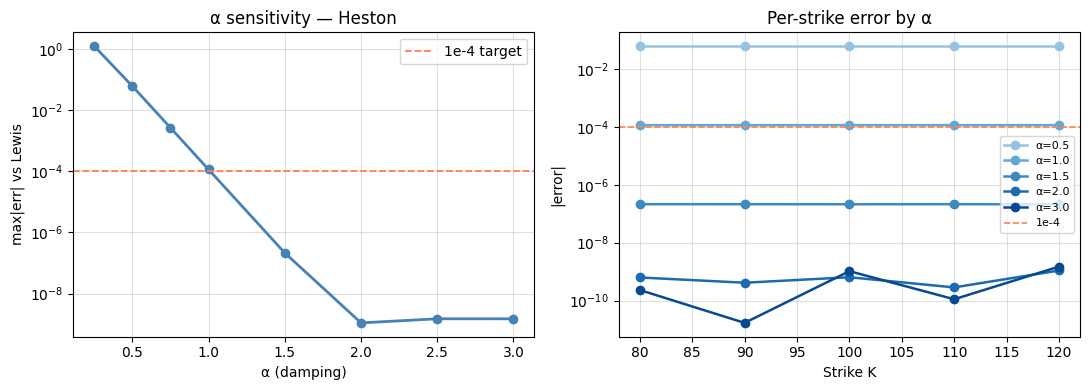

Best α = 2.0  →  max|err| = 1.10e-09
Regularity upper bound ≈ κ/(|ρ|·ν) - 1 = 7.00


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: max error vs alpha
ax = axes[0]
valid_a = sorted(alpha_errs)
max_errs = [alpha_errs[a].max() for a in valid_a]
ax.semilogy(valid_a, max_errs, 'o-', color='steelblue', lw=2)
ax.axhline(1e-4, color='coral', ls='--', lw=1.3, label='1e-4 target')
ax.set(xlabel='α (damping)', ylabel='max|err| vs Lewis', title='α sensitivity — Heston')
ax.legend(); ax.grid(alpha=.4)

# Right: per-strike error heatmap for selected alphas
ax = axes[1]
selected = [0.5, 1.0, 1.5, 2.0, 3.0]
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(selected)))
for a, col in zip(selected, colors):
    if a in alpha_errs:
        ax.semilogy(K_l, alpha_errs[a], 'o-', color=col, lw=1.8, label=f'α={a}')
ax.set(xlabel='Strike K', ylabel='|error|', title='Per-strike error by α')
ax.axhline(1e-4, color='coral', ls='--', lw=1.2, label='1e-4')
ax.legend(fontsize=8); ax.grid(alpha=.4)

plt.tight_layout(); plt.savefig('02a_alpha.png', dpi=120, bbox_inches='tight')
plt.show()

best_a = min(alpha_errs, key=lambda a: alpha_errs[a].max())
print(f"Best α = {best_a}  →  max|err| = {alpha_errs[best_a].max():.2e}")
print(f"Regularity upper bound ≈ κ/(|ρ|·ν) - 1 = {4/(0.5*1.0)-1:.2f}")


## TODO B — Grid sensitivity: N and η

Nyquist constraint: $\eta\lambda=2\pi/N$.  Larger $N$ → finer log-strike grid; smaller $\eta$ → wider strike range.  This shows the minimum $N$ to hit $10^{-4}$ — motivating FRFT (notebook 03).

In [8]:
# ── B1: vary N at fixed η=0.25 ────────────────────────────────────────────────
N_list = [64, 128, 256, 512, 1024, 2048, 4096]
N_errs, N_times = [], []

print("N grid sensitivity (η=0.25 fixed):")
print(f"{'N':>6}  {'max|err|':>12}  {'time (ms)':>11}  pass(1e-4)?")
for N in N_list:
    t0 = time.perf_counter()
    C_N = fft_price(phi_h, K_l, rh, Th, N=N, eta=0.25)
    dt  = (time.perf_counter()-t0)*1e3
    err = np.abs(C_N-REF).max()
    N_errs.append(err); N_times.append(dt)
    print(f"  {N:5d}  {err:12.2e}  {dt:11.2f}  {'✓' if err<1e-4 else '✗'}")


N grid sensitivity (η=0.25 fixed):
     N      max|err|    time (ms)  pass(1e-4)?
     64      5.21e-02         1.32  ✗
    128      3.65e-03         0.96  ✗
    256      8.81e-05         1.11  ✓
    512      1.12e-05         1.94  ✓
   1024      4.28e-07         1.11  ✓
   2048      2.14e-07         1.89  ✓
   4096      2.13e-07         3.55  ✓


In [9]:
# ── B2: vary η at fixed N=4096 ────────────────────────────────────────────────
eta_list = [0.05, 0.10, 0.15, 0.25, 0.40, 0.50]
eta_errs = []

print("η sensitivity (N=4096 fixed):")
print(f"{'η':>6}  {'λ (log-K step)':>16}  {'max|err|':>12}  pass(1e-4)?")
for eta in eta_list:
    lam = 2*np.pi/(4096*eta)
    C_e = fft_price(phi_h, K_l, rh, Th, N=4096, eta=eta)
    err = np.abs(C_e-REF).max()
    eta_errs.append(err)
    print(f"  {eta:.2f}  {lam:16.6f}  {err:12.2e}  {'✓' if err<1e-4 else '✗'}")


η sensitivity (N=4096 fixed):
     η    λ (log-K step)      max|err|  pass(1e-4)?
  0.05          0.030680      6.45e-07  ✓
  0.10          0.015340      7.89e-08  ✓
  0.15          0.010227      1.37e-08  ✓
  0.25          0.006136      2.13e-07  ✓
  0.40          0.003835      2.50e-04  ✗
  0.50          0.003068      2.63e-03  ✗


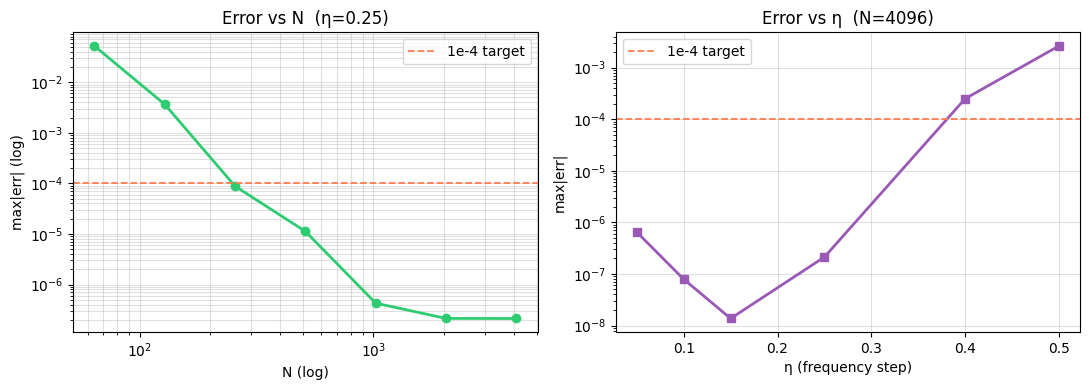

Minimum N to achieve 1e-4: 256  — FRFT hits same accuracy at N=16


In [10]:
fig, axes = plt.subplots(1,2, figsize=(11,4))

ax = axes[0]
ax.loglog(N_list, N_errs, 'o-', color='#2ecc71', lw=2)
ax.axhline(1e-4, color='coral', ls='--', lw=1.3, label='1e-4 target')
ax.set(xlabel='N (log)', ylabel='max|err| (log)', title='Error vs N  (η=0.25)')
ax.legend(); ax.grid(alpha=.4, which='both')

ax = axes[1]
ax.semilogy(eta_list, eta_errs, 's-', color='#9b59b6', lw=2)
ax.axhline(1e-4, color='coral', ls='--', lw=1.3, label='1e-4 target')
ax.set(xlabel='η (frequency step)', ylabel='max|err|', title='Error vs η  (N=4096)')
ax.legend(); ax.grid(alpha=.4)

plt.tight_layout(); plt.savefig('02b_grid.png', dpi=120, bbox_inches='tight')
plt.show()

min_N_ok = next(N for N,e in zip(N_list,N_errs) if e < 1e-4)
print(f"Minimum N to achieve 1e-4: {min_N_ok}  — FRFT hits same accuracy at N=16")


## Speed comparison — FFT vs MC

In [11]:
# MC pricer (inline, no import needed)
def sim_var_exact_local(v0, kappa, theta, nu, T, n_paths, n_steps, rng):
    h=T/n_steps; df=4*kappa*theta/nu**2; v=np.full(n_paths,v0)
    VT=v*(h/2)
    for s in range(1,n_steps+1):
        c=nu**2*(1-np.exp(-kappa*h))/(4*kappa)
        v=c*rng.noncentral_chisquare(df,v*np.exp(-kappa*h)/c,n_paths)
        v=np.maximum(v,0); VT+=v*(h/2 if s==n_steps else h)
    return v, VT

N_list2=[10,100,1000]; mc_t=[]; fft_t=[]
kappa_t,theta_t,nu_t,rho_t,v0_t = 4.,0.25,1.,-0.5,0.04
rho_star_t = np.sqrt(1-rho_t**2)

for n_k in N_list2:
    K_arr = np.linspace(70,130,n_k)

    # MC timing
    t0 = time.perf_counter()
    rng2 = np.random.default_rng(0)
    v_T, V_T = sim_var_exact_local(v0_t,kappa_t,theta_t,nu_t,1.,50_000,100,rng2)
    adj    = (rho_t/nu_t)*(v_T-v0_t+kappa_t*(V_T-theta_t*1.))
    F0     = 100.*np.exp((rh-qh)*1.)
    S_adj  = F0*np.exp(adj-(rho_t**2/2)*V_T)
    sig_c  = rho_star_t*np.sqrt(np.maximum(V_T,1e-14))
    _ = [np.exp(-rh)*np.mean(bs_call(S_adj,k,1.,0,sig_c)) for k in K_arr]
    mc_t.append((time.perf_counter()-t0)*1e3)

    # FFT timing
    t0 = time.perf_counter()
    for _ in range(20): fft_price(phi_h, K_arr, rh, Th)
    fft_t.append((time.perf_counter()-t0)/20*1e3)

print(f"{'N':>6}  {'MC (ms)':>10}  {'FFT (ms)':>10}  {'speedup':>10}")
for n,m,f in zip(N_list2,mc_t,fft_t):
    print(f"  {n:4d}  {m:10.1f}  {f:10.2f}  {m/f:9.0f}×")


     N     MC (ms)    FFT (ms)     speedup
    10       397.5        3.05        131×
   100       715.5        2.42        295×
  1000      4631.2        2.76       1681×


In [12]:
print("\nPhase 2 summary")
print("─"*50)
print(f"  VG   CM1999 Case 4   max|err| = {np.abs(P_vg-REF_VG).max():.2e}  target 1e-4")
print(f"  Heston Lewis (2001)  max|err| = {np.abs(C_l-REF).max():.2e}  target 1e-4")
print(f"  Best α = {best_a}   |   Min N for 1e-4 = {min_N_ok}")
print(f"  FRFT motivation: same accuracy at N=16 vs N={min_N_ok}  →  next notebook")



Phase 2 summary
──────────────────────────────────────────────────
  VG   CM1999 Case 4   max|err| = 3.88e-05  target 1e-4
  Heston Lewis (2001)  max|err| = 2.13e-07  target 1e-4
  Best α = 2.0   |   Min N for 1e-4 = 256
  FRFT motivation: same accuracy at N=16 vs N=256  →  next notebook
